In [4]:
from google.colab import drive
drive.mount('/content/drive')        # you will be asked for authorization

!pip install -q datasets tiktoken

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
import torch
import tiktoken
from pretraining import (
    create_dataloader_fineweb, make_fixed_eval_loaders,
    GPT_CONFIG_124M, train_model_simple)
from Transformer_arquitectures import GPTModel

device = torch.device("cuda" if torch.cuda.is_available()
                      else "mps" if torch.backends.mps.is_available()
                      else "cpu")
print("PyTorch:", torch.__version__)
print("Device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
Device: cuda
GPU: Tesla T4


In [6]:
# ── Configuration (adjust to taste) ──
MAX_DOCS    = 5000    # training documents (~1-2k tokens each)
MAX_LENGTH  = 256    # context (lower to 256 if it runs slowly)
BATCH_SIZE  = 2
VAL_MOD     = 100     # 1 validation document every 100
SEED        = 123
EVAL_FREQ   = 100
SAVE_EVERY  = 500     # checkpoint on Drive every 500 steps
CHECKPOINT_DIR = "/content/drive/MyDrive/llm/checkpoints"
# ────────────────────────────────────

train_loader, val_loader = create_dataloader_fineweb(
    batch_size=BATCH_SIZE, max_length=MAX_LENGTH, val_mod=VAL_MOD,
    seed=SEED, max_docs=MAX_DOCS)

train_eval_loader, val_eval_loader = make_fixed_eval_loaders(
    train_loader, val_loader, max_train_batches=8, max_val_batches=16)

xb, yb = next(iter(train_loader))
print("Batch:", xb.shape, "| target == shifted input:",
      torch.equal(yb[:, :-1], xb[:, 1:]))

README.md:   0%|          | 0.00/1.53k [00:00<?, ?B/s]

Batch: torch.Size([2, 256]) | target == input desplazado: True


In [7]:
from datasets import load_dataset

enc = tiktoken.get_encoding("gpt2")
stream = load_dataset("codelion/fineweb-edu-1B", split="train", streaming=True)
stream = stream.shuffle(seed=SEED, buffer_size=10000)

n_docs, n_tokens = 0, 0
for ex in stream:
    n_tokens += len(enc.encode(ex["text"]))
    n_docs += 1
    if n_docs >= 100:
        break

avg = n_tokens / n_docs
est_tokens = avg * MAX_DOCS
print(f"Average: {avg:.0f} tokens/document (sample of {n_docs} docs)")
print(f"Estimated training tokens (max_docs={MAX_DOCS}): ~{est_tokens/1e6:.1f}M")
print(f"Estimated steps (batch {BATCH_SIZE} x {MAX_LENGTH}): ~{est_tokens / (BATCH_SIZE * MAX_LENGTH):.0f}")

Promedio: 1177 tokens/documento (muestra de 100 docs)
Tokens de entrenamiento estimados (max_docs=5000): ~5.9M
Pasos estimados (batch 2 x 256): ~11491


In [8]:
cfg = {**GPT_CONFIG_124M, "context_length": MAX_LENGTH}

torch.manual_seed(SEED)
model = GPTModel(cfg)
model.to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {n_params:,}  ({n_params/1e6:.1f}M)")

optimizer = torch.optim.AdamW(model.parameters(), lr=0.0004, weight_decay=0.1)
tokenizer = tiktoken.get_encoding("gpt2")

Parámetros del modelo: 162,419,712  (162.4M)


In [9]:
train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=1, eval_freq=EVAL_FREQ, eval_iter=1,
    start_context="Every effort moves you", tokenizer=tokenizer,
    eval_train_loader=train_eval_loader, eval_val_loader=val_eval_loader)

Ep 1 (Step 000000): Train loss 8.411, Val loss 10.149
Ep 1 (Step 000100): Train loss 6.967, Val loss 7.214
Ep 1 (Step 000200): Train loss 7.012, Val loss 7.088
Ep 1 (Step 000300): Train loss 6.984, Val loss 6.996
Ep 1 (Step 000400): Train loss 7.225, Val loss 7.100
Ep 1 (Step 000500): Train loss 7.076, Val loss 6.668
Ep 1 (Step 000600): Train loss 6.977, Val loss 6.621
Ep 1 (Step 000700): Train loss 7.089, Val loss 6.817
Ep 1 (Step 000800): Train loss 6.982, Val loss 6.649
Ep 1 (Step 000900): Train loss 6.884, Val loss 6.441
Ep 1 (Step 001000): Train loss 6.852, Val loss 6.378
Ep 1 (Step 001100): Train loss 6.936, Val loss 6.443
Ep 1 (Step 001200): Train loss 6.904, Val loss 6.423
Ep 1 (Step 001300): Train loss 6.841, Val loss 6.455
Ep 1 (Step 001400): Train loss 6.886, Val loss 6.343
Ep 1 (Step 001500): Train loss 6.877, Val loss 6.335
Ep 1 (Step 001600): Train loss 6.864, Val loss 6.246
Ep 1 (Step 001700): Train loss 6.659, Val loss 6.364
Ep 1 (Step 001800): Train loss 6.844, Val los

In [10]:
print("=" * 55)
print(f"Training tokens seen: {tokens_seen[-1]:,}  ({tokens_seen[-1]/1e6:.1f}M)")
print(f"Final train loss: {train_losses[-1]:.3f}")
print(f"Final val loss:   {val_losses[-1]:.3f}")
print("=" * 55)

import os
import torch

# Create folder if it does not exist
os.makedirs("/content/drive/MyDrive/llm", exist_ok=True)

# Save model
torch.save(
    model.state_dict(),
    "/content/drive/MyDrive/llm/gpt2-fineweb.pth"
)

print("✅ Model saved successfully.")

Tokens de entrenamiento vistos: 5,171,712  (5.2M)
Loss train final: 6.260
Loss val final:   5.844
✅ Modelo guardado correctamente.


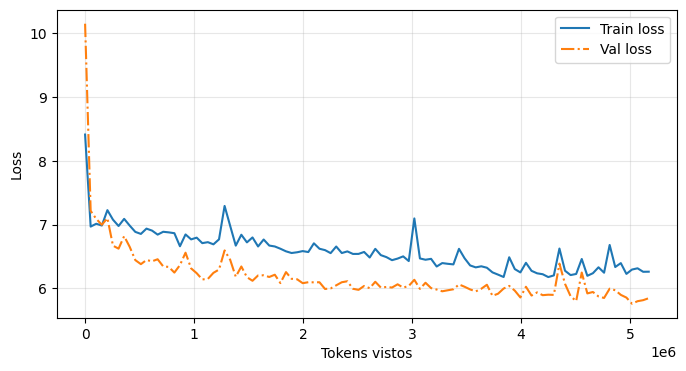

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(tokens_seen, train_losses, label="Train loss")
plt.plot(tokens_seen, val_losses, linestyle="-.", label="Val loss")
plt.xlabel("Tokens seen")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()